# Phase 1 - BigQuery Notebook

In this notebook I'm setting up a Google Cloud Project to query news coverage data for the 2026 Cortina-Milano Winter Olympics. The 2026 Winter Olympics were held from **February 6-22, 2026**. 

Enabled APIs
- BigQuery API
- BigQuery Storage API

Data source:
- GDELT

This notebook will deal with:
- Infrastructure setup
- Data pipeline
- Build an article relevance ladder
- Export an article candidate dataset

In [4]:
import sys
!{sys.executable} -m pip install -q -U google-cloud-bigquery google-cloud-bigquery-storage pyarrow db-dtypes pandas-gbq

In [5]:
# check environment
print(sys.executable)

/opt/anaconda3/envs/ds266-hf-mac/bin/python


In [6]:
# connect to Big Query Project on Google Cloud
import os
from google.cloud import bigquery
from google.oauth2 import service_account

# I REMOVED MY KEY PATH -> INSERT YOUR OWN GOOGLE CLOUD KEY IF YOU WISH TO REPLICATE THIS NOTEBOOK
KEY_PATH = "/your/key/path/key.json"
PROJECT_ID = "sagb-olympics-nlp"

creds = service_account.Credentials.from_service_account_file(KEY_PATH)
client = bigquery.Client(project=PROJECT_ID, credentials=creds)

print("Connected project:", client.project)

Connected project: sagb-olympics-nlp


In [7]:
# Test Query for Sanity Check
query = "SELECT 1 AS ok"
df = client.query(query).to_dataframe()
df

,ok
0,1


## 1. Query News Coverage

The V2Themes does not necessarily include the tag *OLYMPICS*, so I'm querying by DocumentIdentifiers that contain certain regex patterns. I will use four tiers:

1. Tier STRICT: Milano-Cortina / Winter Olympics explicitly (rel_strict)
2. Tier CONTEXTUAL: Medal/games + host/winter context (rel_context)
3. Tier BROAD: olymp* anywhere (rel_olymp)
4. Tier HOST LOCATION: Milano/Cortina (rel_host_loc)


In [9]:
import pandas as pd
from pathlib import Path
import re
import matplotlib.pyplot as plt

In [10]:
# Inspect GDELT database
table_id = "gdelt-bq.gdeltv2.gkg"
table = client.get_table(table_id)
[(s.name, s.field_type) for s in table.schema[:15]]

[('GKGRECORDID', 'STRING'),
 ('DATE', 'INTEGER'),
 ('SourceCollectionIdentifier', 'INTEGER'),
 ('SourceCommonName', 'STRING'),
 ('DocumentIdentifier', 'STRING'),
 ('Counts', 'STRING'),
 ('V2Counts', 'STRING'),
 ('Themes', 'STRING'),
 ('V2Themes', 'STRING'),
 ('Locations', 'STRING'),
 ('V2Locations', 'STRING'),
 ('Persons', 'STRING'),
 ('V2Persons', 'STRING'),
 ('Organizations', 'STRING'),
 ('V2Organizations', 'STRING')]

In [11]:
# gkg_feb2026_relevance_ladder.sql
# Feb 2026 Milano-Cortina / Winter Olympics candidate set + relevance ladder flags
# Table: gdelt-bq.gdeltv2.gkg
# DATE is INTEGER in format YYYYMMDDHHMMSS

QUERY = """

WITH base AS (
  SELECT
    DATE(PARSE_TIMESTAMP('%Y%m%d%H%M%S', CAST(DATE AS STRING))) AS day,
    DATE AS datetime_int,
    DocumentIdentifier AS url,
    SourceCommonName AS source,
    V2Themes AS themes,
    V2Persons AS persons,
    V2Organizations AS orgs,
    V2Locations AS locations,
    V2Tone AS v2tone_raw
  FROM `gdelt-bq.gdeltv2.gkg`
  WHERE DATE BETWEEN 20260201000000 AND 20260228235959
),

scored AS (
  SELECT
    *,
    -- Tier 1: strict Milano-Cortina / Winter Olympics phrasing in URL
    REGEXP_CONTAINS(LOWER(url),
      r'(milano[-_]?cortina|milan[-_]?cortina|winter[-_]?olymp|milano.*olymp|cortina.*olymp)') AS rel_strict,

    -- Tier 2: contextual sports terms with host/winter context 
    (
      REGEXP_CONTAINS(LOWER(url), r'(medal|medals|gold|silver|bronze|closing-ceremony|opening-ceremony|podium|finals?)')
      AND REGEXP_CONTAINS(LOWER(url), r'(milano|milan|cortina|winter)')
    ) AS rel_context,

    -- Tier 3: broad Olympics keyword
    REGEXP_CONTAINS(LOWER(url), r'\bolymp(ic|ics)?\b') AS rel_olymp,

    -- Helper: host location mention
    REGEXP_CONTAINS(LOWER(url), r'\b(milano|milan|cortina)\b') AS rel_host_loc
  FROM base
),

filtered AS (
  SELECT
    *,
    (rel_strict OR rel_context OR rel_olymp) AS rel_combined
  FROM scored
)

SELECT
  day,
  datetime_int,
  url,
  source,
  themes,
  persons,
  orgs,
  locations,
  v2tone_raw,
  rel_strict,
  rel_context,
  rel_olymp,
  rel_host_loc,
  rel_combined
FROM filtered
WHERE
  (
    rel_strict
    OR rel_olymp
    OR rel_context
    OR (rel_host_loc AND REGEXP_CONTAINS(LOWER(url), r'(olymp|winter)'))
    OR REGEXP_CONTAINS(LOWER(themes), r'(olympic|winter_olympic)')
  )
LIMIT 200000;
"""
df = client.query(QUERY).to_dataframe()
df.shape

(30565, 14)

In [12]:
df.head()

,day,datetime_int,url,source,themes,persons,orgs,locations,v2tone_raw,rel_strict,rel_context,rel_olymp,rel_host_loc,rel_combined
0,2026-02-27,20260227210000,https://www.zazoom.it/2026-02-27/la-fiamma-par...,zazoom.it,None,"Square Mark,2283",None,"5#Trentino, Trentino-Alto Adige, Italy#IT#IT17...","1.85676392572944,2.12201591511936,0.2652519893...",True,False,False,False,True
1,2026-02-27,20260227223000,https://www.newsday.co.zw/news/article/2000520...,newsday.co.zw,"TAX_FNCACT_MAN,371;TAX_FNCACT_MAN,2023;TAX_FNC...","Matthew Ziburis,2343;Alysa Liu,10;Alysa Liu,49...","Chinese Communist Party,413;Chinese Communist ...","3#Hollywood, California, United States#US#USCA...","-3.05263157894737,2.94736842105263,6,8.9473684...",True,False,False,False,True
2,2026-02-27,20260227200000,https://thesil.ca/mcmaster-athletes-show-out-i...,thesil.ca,None,"Madeline Schizas,16",None,1#Canadian#CA#CA##60#-96#CA#2122;1#Canadian#CA...,"2.07373271889401,2.30414746543779,0.2304147465...",True,False,False,False,True
3,2026-02-27,20260227214500,https://www.cinemablend.com/television/is-alys...,cinemablend.com,None,"Kaori Sakamoto,2043;Johnny Weir,862;Alysa Liu,...","Olympics,101;Olympics,547;Olympics,890;Olympic...","4#Milan, Lombardia, Italy#IT#IT09#18363#45.466...","2.83018867924528,3.77358490566038,0.9433962264...",True,True,False,False,True
4,2026-02-27,20260227203000,https://wdet.org/2026/02/25/the-metro-team-usa...,wdet.org,"TAX_FNCACT_PRODUCER,48;TAX_FNCACT_PRODUCER,107...",None,"Detroit Free Press,303;Detroit Free,297",None,"0,1.53846153846154,1.53846153846154,3.07692307...",True,True,False,False,True


In [13]:
# Check distribution of across Tier Filters
df[["rel_strict","rel_olymp","rel_context","rel_host_loc"]].value_counts()

rel_strict  rel_olymp  rel_context  rel_host_loc
True        False      False        False           24377
                       True         False            5165
False       False      True         False            1020
                       False        False               3
Name: count, dtype: int64

In [14]:
# Parse tone + add relevance flag
def tone_first(t):
    try:
        return float(str(t).split(",")[0])
    except:
        return None

df["tone"] = df["v2tone_raw"].apply(tone_first)

df["is_relevant"] = (
    df["themes"].fillna("").str.contains("OLYMPIC", case=False)
    | df["url"].fillna("").str.contains("olymp|milano|milan|cortina", case=False, regex=True)
)

df[["day","source","url","tone","is_relevant"]].head()

,day,source,url,tone,is_relevant
0,2026-02-27,zazoom.it,https://www.zazoom.it/2026-02-27/la-fiamma-par...,1.856764,True
1,2026-02-27,newsday.co.zw,https://www.newsday.co.zw/news/article/2000520...,-3.052632,True
2,2026-02-27,thesil.ca,https://thesil.ca/mcmaster-athletes-show-out-i...,2.073733,True
3,2026-02-27,cinemablend.com,https://www.cinemablend.com/television/is-alys...,2.830189,True
4,2026-02-27,wdet.org,https://wdet.org/2026/02/25/the-metro-team-usa...,0.000000,True


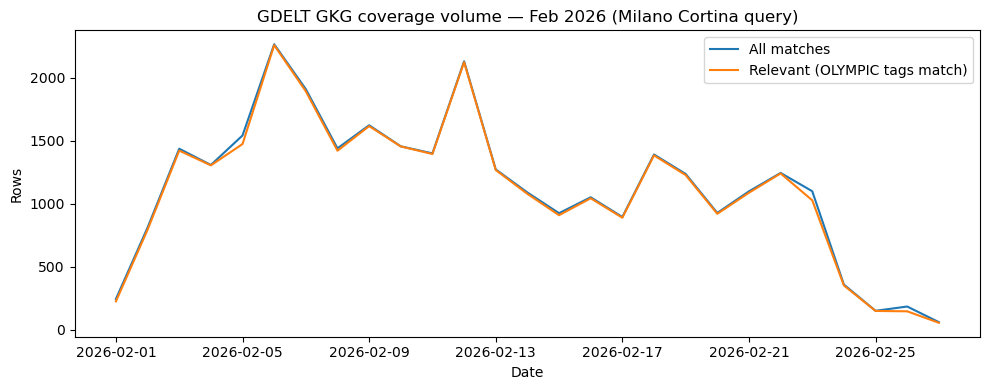

PosixPath('../figures/phase1_daily_volume.png')

In [15]:
# Plot data for sanity check
fig_dir = Path("../figures")
fig_dir.mkdir(exist_ok=True)

daily_total = df.groupby("day").size().sort_index()
daily_rel = df[df["is_relevant"]].groupby("day").size().sort_index()

plt.figure(figsize=(10,4))
plt.plot(daily_total.index, daily_total.values, label="All matches")
plt.plot(daily_rel.index, daily_rel.values, label="Relevant (OLYMPIC tags match)")
plt.title("GDELT GKG coverage volume — Feb 2026 (Milano Cortina query)")
plt.xlabel("Date")
plt.ylabel("Rows")
plt.legend()
plt.tight_layout()

fig_path = fig_dir / "phase1_daily_volume.png"
plt.savefig(fig_path, dpi=200)
plt.show()

fig_path

In [16]:
# Summary table of available articles per tier
total_n = len(df)

summary = pd.DataFrame({
    "tier": ["Strict (Milano-Cortina + Winter phrasing)",
             "Winter Olympics (olymp keyword)",
             "Host Location Mention (Milan/Cortina)"],
    "count": [
        df["rel_strict"].sum(),
        df["rel_olymp"].sum(),
        df["rel_host_loc"].sum()
    ]
})

summary["percent_of_total"] = (summary["count"] / total_n * 100).round(2)

summary.style.format({
    "count": "{:,.0f}",
    "percent_of_total": "{:.2f}%"
})

,tier,count,percent_of_total
0,Strict (Milano-Cortina + Winter phrasing),"29,542",96.65%
1,Winter Olympics (olymp keyword),0,0.00%
2,Host Location Mention (Milan/Cortina),0,0.00%


In [17]:
# Export df to repo (data/)
data_dir = Path("../data")
data_dir.mkdir(exist_ok=True)

out = data_dir / "gdelt_gkg_feb2026_relevance_ladder.parquet"

# format datetime for export
df["day"] = pd.to_datetime(df["day"])
df["tone_raw"] = df["v2tone_raw"].astype(str)

# export
df.to_parquet(out, index=False)
out

PosixPath('../data/gdelt_gkg_feb2026_relevance_ladder.parquet')

In [18]:
# Export summary to Repo
summary_path = Path("../data/phase1_relevance_summary.csv")
summary.to_csv(summary_path, index=False)

summary_path

PosixPath('../data/phase1_relevance_summary.csv')